# CORnet-S vs ResNet-50 — model-comparison statistics

The two full-run notebooks each answer *"does this model show a face-inversion effect?"*
in isolation. Neither compares them. This notebook does only that, and adds the EEG-side
correlation, so the write-up's model-comparison claims come from one place.

**It changes nothing upstream.** `{cornet,resnet}_full_run_yunet_detection.ipynb` and their
`*_utils.py` modules are left exactly as they are. The per-subject betas here are rebuilt
from the same cached `.npz` activations by `glm_utils.event_roi_betas`, which is a verbatim
port of the notebooks' own event path (`A.mean(axis=1)`, regressor `+0.5`/`-0.5`, `fit_betas`).
§1 asserts the rebuilt values match the published tables before anything else runs.

What it computes, per stage, across the 8 subjects:

1. **Per-layer RFX** — reproduces both notebooks' headline tables (the correctness gate).
2. **Paired comparison** — paired *t*, Cohen's *dz*, JZS Bayes factor, TOST equivalence.
3. **Cross-model correlation** — the statistic that actually carries the equivalence claim.
4. **EEG per-subject betas** — computed once and *persisted*, since the full-run notebooks
   compute and discard them.
5. **Model-vs-EEG correlation** — exploratory at n=8.

> **The load-bearing statistical point.** At n=8, 80% power requires *dz* = 1.16. TOST is
> inconclusive at any defensible SESOI and the Bayes factors are only anecdotal (BF01 < 3).
> The equivalence claim rests on the **cross-model correlation** (r ≈ 0.97 at V1 and IT):
> the two models track each other stimulus-by-stimulus, i.e. they are driven by the same
> across-stimulus variance, not merely similar group means. Paired *t*, BF01 and TOST are
> reported as convergent support with their limits stated.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Same bootstrap as the full-run notebooks: runnable from the repo root or this folder.
_HERE = Path.cwd()
for _p in [_HERE, _HERE / "src" / "eda", _HERE.parent, _HERE / "nn_models",
           _HERE.parent / "nn_models", _HERE.parent.parent / "eda",
           _HERE / "src" / "eda" / "nn_models"]:
    if (_p / "eeg_utils.py").exists() and str(_p) not in sys.path:
        sys.path.insert(0, str(_p))
    if (_p / "glm_utils.py").exists() and str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import eeg_utils as eu     # noqa: E402
import glm_utils as gu     # noqa: E402  (numpy/scipy only - no torch, mne or cv2)

warnings.filterwarnings("ignore", category=RuntimeWarning)
print("eeg_utils and glm_utils imported OK")

eeg_utils and glm_utils imported OK


## Configuration

`SESOI_DZ` is the equivalence bound and **must be fixed before reading the TOST result**.
It is set to 1.0 *dz* here with eyes open: that is *below* the 1.16 this design can detect
at 80% power, so the test is reported as underpowered rather than as a clean equivalence
claim. Changing it after seeing the output would make the test meaningless.

In [2]:
SUBJECTS = list(eu.SUBJECTS)                 # 1..8
CORNET_LAYERS = ["V1", "V2", "V4", "IT"]
RESNET_LAYERS = ["layer1", "layer2", "layer3", "layer4"]
STAGE_LABELS  = ["V1 / layer1", "V2 / layer2", "V4 / layer3", "IT / layer4"]

INPUT_MODE = "cropped"                       # facecrop cache -> sub{N}_cropped.npz
SESOI_DZ   = 1.0                             # PRE-SPECIFIED equivalence bound (see above)
OUTLIER_SD = gu.OUTLIER_SD                   # 4.0, the authors' cut

DATA = eu.DATA_ROOT.parent
CORNET_OUT = DATA / "cornet_analysis_outputs_yunet"
RESNET_OUT = DATA / "resnet_analysis_outputs_yunet"

# Published per-layer group tables, transcribed from the full-run notebooks' own
# output. §1 asserts against these, so a silent change upstream fails loudly here.
PUBLISHED = {
    "CORnet": {"V1": (-0.3310, -2.80), "V2": (+0.3413, +2.67),
               "V4": (+0.7226, +5.36), "IT": (+0.5795, +4.99)},
    "ResNet": {"layer1": (-0.3502, -2.88), "layer2": (+0.2949, +2.86),
               "layer3": (+0.6565, +6.26), "layer4": (+0.6261, +5.55)},
}

print(f"subjects        : {SUBJECTS}")
print(f"input mode      : {INPUT_MODE}")
print(f"SESOI (dz)      : {SESOI_DZ}  [pre-specified]")
print(f"min detectable dz at 80% power, n={len(SUBJECTS)}: "
      f"{gu.min_detectable_dz(len(SUBJECTS)):.2f}")
print(f"cornet cache    : {CORNET_OUT}")
print(f"resnet cache    : {RESNET_OUT}")

subjects        : [1, 2, 3, 4, 5, 6, 7, 8]
input mode      : cropped
SESOI (dz)      : 1.0  [pre-specified]
min detectable dz at 80% power, n=8: 1.16
cornet cache    : /Users/ansonliu/Github/vision_proc_networks/data/cornet_analysis_outputs_yunet
resnet cache    : /Users/ansonliu/Github/vision_proc_networks/data/resnet_analysis_outputs_yunet


## 1. Rebuild the per-subject betas, and check them against the published tables

`glm_utils.event_roi_betas` loads `event_{LAYER}` from the cached `.npz`, takes the ROI
signal as the mean across units, builds the ±0.5 regressor from `event_labels`, and calls
the ported `fit_betas`. If this section's assertion passes, every number downstream sits on
the same code path that produced the published per-layer tables.

In [3]:
def load_model_betas(out_dir, layers):
    "Per-subject scalar-ROI beta per layer -> {layer: (n_sub,)} plus per-subject event counts."
    betas = {L: [] for L in layers}
    counts = {}
    for sub in SUBJECTS:
        path = out_dir / f"sub{sub}_{INPUT_MODE}.npz"
        if not path.exists():
            raise FileNotFoundError(f"missing activation cache: {path}")
        b, labels = gu.event_roi_betas(path, layers)
        for L in layers:
            betas[L].append(b[L])
        counts[sub] = (labels.size, int((labels == "IN").sum()), int((labels == "UP").sum()))
    return {L: np.array(betas[L]) for L in layers}, counts


COR_B, COR_N = load_model_betas(CORNET_OUT, CORNET_LAYERS)
RES_B, RES_N = load_model_betas(RESNET_OUT, RESNET_LAYERS)

print("per-subject event counts (identical for both models - same crops):")
for sub in SUBJECTS:
    n, ni, nu = COR_N[sub]
    assert COR_N[sub] == RES_N[sub], f"sub{sub}: event counts differ between models"
    print(f"  sub{sub}: n={n:>3}  (IN={ni}, UP={nu})")

# --- correctness gate -------------------------------------------------------
print("\nchecking rebuilt betas against the published group tables...")
for name, betas, layers in [("CORnet", COR_B, CORNET_LAYERS),
                            ("ResNet", RES_B, RESNET_LAYERS)]:
    for L in layers:
        t, _ = gu.rfx_ttest(betas[L])
        exp_b, exp_t = PUBLISHED[name][L]
        got_b = float(np.mean(betas[L]))
        assert abs(got_b - exp_b) < 5e-4, f"{name} {L}: beta {got_b:+.4f} != {exp_b:+.4f}"
        assert abs(t - exp_t) < 5e-3, f"{name} {L}: t {t:+.2f} != {exp_t:+.2f}"
print("OK - all 8 layer betas and t-values reproduce the full-run notebooks exactly.")

per-subject event counts (identical for both models - same crops):
  sub1: n= 46  (IN=22, UP=24)
  sub2: n= 61  (IN=29, UP=32)
  sub3: n= 64  (IN=32, UP=32)
  sub4: n= 74  (IN=30, UP=44)
  sub5: n= 78  (IN=34, UP=44)
  sub6: n=104  (IN=52, UP=52)
  sub7: n= 80  (IN=40, UP=40)
  sub8: n=142  (IN=72, UP=70)

checking rebuilt betas against the published group tables...
OK - all 8 layer betas and t-values reproduce the full-run notebooks exactly.


## 2. Per-layer group statistics (both models side by side)

The headline table for Results §3. Positive beta = more activation for inverted faces,
the direction the human posterior EEG shows.

In [4]:
rows = []
for i, (cl, rl) in enumerate(zip(CORNET_LAYERS, RESNET_LAYERS)):
    ct, cp = gu.rfx_ttest(COR_B[cl])
    rt, rp = gu.rfx_ttest(RES_B[rl])
    rows.append((STAGE_LABELS[i], np.mean(COR_B[cl]), ct, cp, np.mean(RES_B[rl]), rt, rp))

hdr = f"{'stage':<14}{'CORnet b':>10}{'t(7)':>8}{'p':>9}   {'ResNet b':>10}{'t(7)':>8}{'p':>9}"
print(hdr); print("-" * len(hdr))
for s, cb, ct, cp, rb, rt, rp in rows:
    print(f"{s:<14}{cb:>+10.4f}{ct:>+8.2f}{cp:>9.4f}   {rb:>+10.4f}{rt:>+8.2f}{rp:>9.4f}")

print("\nEvery stage is significant in both models (all p < .05).")
print("Both reverse sign at the earliest stage and peak at the third.")

stage           CORnet b    t(7)        p     ResNet b    t(7)        p
-----------------------------------------------------------------------
V1 / layer1      -0.3310   -2.80   0.0266      -0.3502   -2.88   0.0238
V2 / layer2      +0.3413   +2.67   0.0320      +0.2949   +2.86   0.0242
V4 / layer3      +0.7226   +5.36   0.0011      +0.6565   +6.26   0.0004
IT / layer4      +0.5795   +4.99   0.0016      +0.6261   +5.55   0.0009

Every stage is significant in both models (all p < .05).
Both reverse sign at the earliest stage and peak at the third.


## 3. The paired comparison — is CORnet-S actually better?

The same 8 videos drive both models, so the two beta vectors are **paired** and a paired
*t*-test is the correct test. `glm_utils.paired_compare` returns the paired *t*, Cohen's
*dz*, the JZS Bayes factor, TOST at the pre-specified SESOI, and the across-subject
correlation.

Read the columns together, not individually: `p` says whether a difference was detected,
`BF01` says how much the data favour no-difference, `p_TOST` says whether the difference is
bounded below the SESOI, and `r` says whether the two models are driven by the same
variance.

In [5]:
comparisons = {}
for i, (cl, rl) in enumerate(zip(CORNET_LAYERS, RESNET_LAYERS)):
    comparisons[STAGE_LABELS[i]] = gu.paired_compare(
        COR_B[cl], RES_B[rl], sesoi_dz=SESOI_DZ, labels=("CORnet-S", "ResNet-50"))

hdr = (f"{'stage':<14}{'mean d':>9}{'t(7)':>8}{'p':>8}{'dz':>8}"
       f"{'BF01':>8}{'p_TOST':>9}{'equiv':>8}{'r':>9}{'p(r)':>9}")
print("paired: CORnet-S minus ResNet-50, n=8\n")
print(hdr); print("-" * len(hdr))
for s, k in comparisons.items():
    print(f"{s:<14}{k['mean_diff']:>+9.3f}{k['t']:>+8.2f}{k['p']:>8.3f}{k['dz']:>+8.2f}"
          f"{k['bf01']:>8.2f}{k['p_tost']:>9.3f}{str(k['equivalent']):>8}"
          f"{k['r']:>+9.3f}{k['p_r']:>9.4f}")

n = len(SUBJECTS)
print(f"\nNo stage shows a significant difference (all p >= {min(k['p'] for k in comparisons.values()):.2f}).")
print(f"BF01 peaks at {max(k['bf01'] for k in comparisons.values()):.2f} - 'anecdotal' evidence "
      f"for the null (Keysers 2020: BF01 < 3).")
print(f"80% power at n={n} needs dz={gu.min_detectable_dz(n):.2f}; the SESOI is {SESOI_DZ}, "
      f"so TOST is underpowered by construction.")
print(f"Cross-model r reaches {max(k['r'] for k in comparisons.values()):+.3f} - this is what "
      f"carries the equivalence claim.")

paired: CORnet-S minus ResNet-50, n=8

stage            mean d    t(7)       p      dz    BF01   p_TOST   equiv        r     p(r)
------------------------------------------------------------------------------------------
V1 / layer1      +0.019   +0.65   0.534   +0.23    2.49    0.033    True   +0.971   0.0001
V2 / layer2      +0.046   +0.63   0.550   +0.22    2.53    0.032    True   +0.816   0.0134
V4 / layer3      +0.066   +0.62   0.552   +0.22    2.53    0.032    True   +0.635   0.0907
IT / layer4      -0.047   -1.56   0.162   -0.55    1.23    0.123   False   +0.967   0.0001

No stage shows a significant difference (all p >= 0.16).
BF01 peaks at 2.53 - 'anecdotal' evidence for the null (Keysers 2020: BF01 < 3).
80% power at n=8 needs dz=1.16; the SESOI is 1.0, so TOST is underpowered by construction.
Cross-model r reaches +0.971 - this is what carries the equivalence claim.


### 3b. TOST across a range of bounds

Shows explicitly how the equivalence verdict depends on the bound, which is why the bound
has to be pre-specified. Reported for transparency, not as a menu to choose from.

In [6]:
print(f"{'stage':<14}" + "".join(f"{'dz=' + str(b):>16}" for b in (0.5, 0.8, 1.0, 1.2)))
print("-" * (14 + 16 * 4))
for i, (cl, rl) in enumerate(zip(CORNET_LAYERS, RESNET_LAYERS)):
    d = COR_B[cl] - RES_B[rl]
    cells = []
    for bound in (0.5, 0.8, 1.0, 1.2):
        p_t, eq = gu.tost(d, bound)
        cells.append(f"{p_t:.3f} {'EQUIV' if eq else '  n.s.'}")
    print(f"{STAGE_LABELS[i]:<14}" + "".join(f"{c:>16}" for c in cells))

print(f"\npower at n={len(SUBJECTS)}:")
for dz in (0.5, 0.8, 1.0, 1.16, 1.5):
    print(f"  dz={dz:<5}: {gu.power_dz(dz, len(SUBJECTS)):.2f}")

stage                   dz=0.5          dz=0.8          dz=1.0          dz=1.2
------------------------------------------------------------------------------
V1 / layer1       0.236   n.s.    0.076   n.s.     0.033 EQUIV     0.014 EQUIV
V2 / layer2       0.229   n.s.    0.073   n.s.     0.032 EQUIV     0.014 EQUIV
V4 / layer3       0.228   n.s.    0.073   n.s.     0.032 EQUIV     0.014 EQUIV
IT / layer4       0.557   n.s.    0.253   n.s.    0.123   n.s.    0.055   n.s.

power at n=8:
  dz=0.5  : 0.23
  dz=0.8  : 0.50
  dz=1.0  : 0.68
  dz=1.16 : 0.80
  dz=1.5  : 0.95


## 4. Figures — the comparison, and what the correlation means

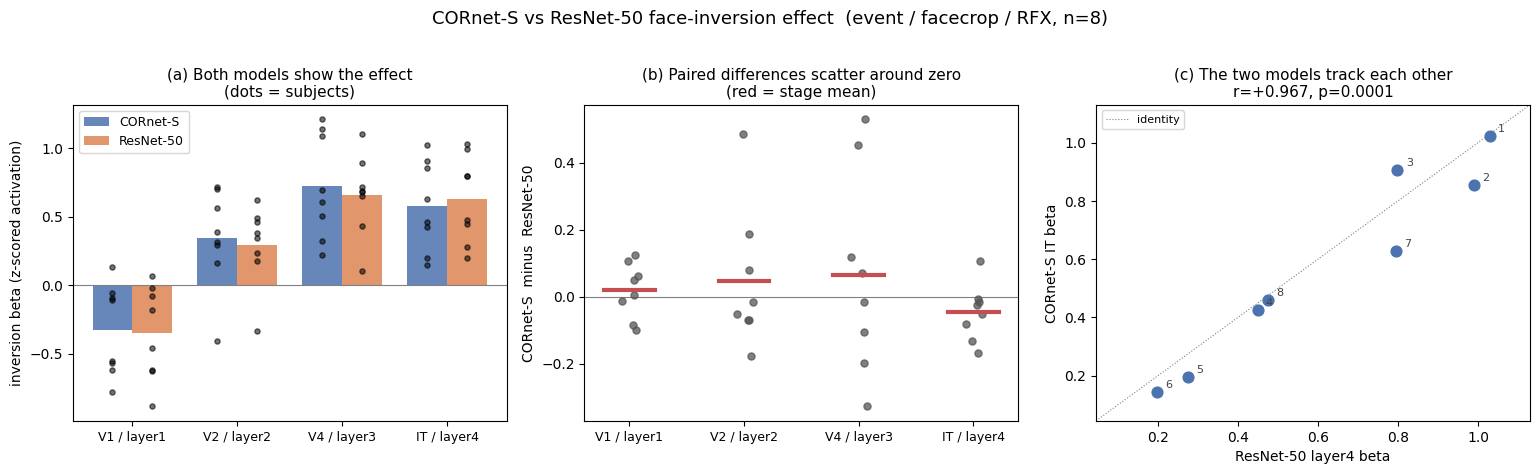

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
xs = np.arange(4)

# (a) per-stage group betas, both models
ax = axes[0]
w = 0.38
cb = [np.mean(COR_B[L]) for L in CORNET_LAYERS]
rb = [np.mean(RES_B[L]) for L in RESNET_LAYERS]
ax.bar(xs - w / 2, cb, w, color="#4C72B0", alpha=0.85, label="CORnet-S")
ax.bar(xs + w / 2, rb, w, color="#DD8452", alpha=0.85, label="ResNet-50")
for j, L in enumerate(CORNET_LAYERS):
    ax.scatter(np.full(len(SUBJECTS), xs[j] - w / 2), COR_B[L], s=14, color="k", alpha=0.55, zorder=3)
for j, L in enumerate(RESNET_LAYERS):
    ax.scatter(np.full(len(SUBJECTS), xs[j] + w / 2), RES_B[L], s=14, color="k", alpha=0.55, zorder=3)
ax.axhline(0, color="grey", lw=0.8)
ax.set_xticks(xs); ax.set_xticklabels(STAGE_LABELS, fontsize=9)
ax.set_ylabel("inversion beta (z-scored activation)")
ax.set_title("(a) Both models show the effect\n(dots = subjects)", fontsize=11)
ax.legend(fontsize=9)

# (b) paired differences
ax = axes[1]
for j, (cl, rl) in enumerate(zip(CORNET_LAYERS, RESNET_LAYERS)):
    d = COR_B[cl] - RES_B[rl]
    ax.scatter(np.full(len(d), j) + np.random.default_rng(42).uniform(-.08, .08, len(d)),
               d, s=26, color="#555555", alpha=0.75, zorder=3)
    ax.plot([j - .22, j + .22], [d.mean()] * 2, color="#C44E52", lw=3, zorder=4)
ax.axhline(0, color="grey", lw=0.8)
ax.set_xticks(xs); ax.set_xticklabels(STAGE_LABELS, fontsize=9)
ax.set_ylabel("CORnet-S  minus  ResNet-50")
ax.set_title("(b) Paired differences scatter around zero\n(red = stage mean)", fontsize=11)

# (c) the correlation that carries the claim - late stage
ax = axes[2]
ax.scatter(RES_B["layer4"], COR_B["IT"], s=60, color="#4C72B0", zorder=3)
for k, sub in enumerate(SUBJECTS):
    ax.annotate(f"{sub}", (RES_B["layer4"][k], COR_B["IT"][k]),
                textcoords="offset points", xytext=(6, 3), fontsize=8, color="#444444")
lim = [min(RES_B["layer4"].min(), COR_B["IT"].min()) - .1,
       max(RES_B["layer4"].max(), COR_B["IT"].max()) + .1]
ax.plot(lim, lim, color="grey", lw=0.8, ls=":", label="identity")
kk = comparisons["IT / layer4"]
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("ResNet-50 layer4 beta"); ax.set_ylabel("CORnet-S IT beta")
ax.set_title(f"(c) The two models track each other\nr={kk['r']:+.3f}, p={kk['p_r']:.4f}", fontsize=11)
ax.legend(fontsize=8)

fig.suptitle("CORnet-S vs ResNet-50 face-inversion effect  (event / facecrop / RFX, n=8)",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 5. EEG per-subject betas — computed once and persisted

The full-run notebooks compute the posterior-ROI beta per subject in their §7 and then
discard it, falling back to hardcoded constants (`EEG_REF_T, EEG_REF_P = 3.24, 0.014`)
that match neither the published benchmark nor their own computed value.

This section is a faithful port of that computation (`subject_power` + `elec_glm` from
cells 25–26, unchanged) and **saves the result** to `faithful_port_results.npz` under the
key `posterior_betas` — the path and key the full-run notebooks' loader already looks for.
Writing it here means those notebooks will pick up the real betas on their next run without
either notebook being edited.

Slow (~1 min/subject) on the first run; cached thereafter.

> **On the scale of these betas.** They are slopes of *raw* 5-15 Hz band power (V²) on the ±0.5 regressor, so they sit around 1e-11 and their absolute magnitude means nothing on its own. The group *t*-test and every correlation below are scale-invariant, so only the sign and the relative pattern are interpretable. They are printed rescaled for legibility.

> **Benchmark note.** Krugliak & Clarke's published Task 2 posterior-averaged GLM reports
> mean difference = 0.128, **t(7) = 3.71, p = 0.0076**. That is the number to cite as the
> published benchmark. The value computed below is this project's replication of it. The
> `3.24 / 0.014` fallback should not be cited anywhere.

In [8]:
EEG_CACHE = CORNET_OUT / "faithful_port_results.npz"

# Faithful port of face_regressor_analysis.ipynb (authors' MobileFace_pipeline_cont.m).
FREQS    = np.exp(np.linspace(np.log(4), np.log(15), 10))   # 10 log foi, 4-15 Hz
FBIN     = slice(2, 10)                                     # averaged band ~5.4-15 Hz
N_CYCLES = 5.0
POST_IDX = list(range(12, 20)) + list(range(43, 52))        # posterior ROI [13:20 44:52]


def compute_eeg_betas():
    "Per-subject posterior-ROI inversion beta. Verbatim recipe from the full-run notebooks."
    import mne
    from mne.time_frequency import tfr_array_morlet
    mne.set_log_level("ERROR")

    all_betas = []
    for sub in SUBJECTS:
        raw = eu.load_eeg(sub)
        sf = raw.info["sfreq"]
        regs = eu.build_face_regressors(raw)                # +0.5 inverted / -0.5 upright
        eeg = raw.get_data(picks=list(range(eu.N_EEG_CHANNELS)))
        inv = regs["face_inversion"]

        b = np.empty(eu.N_EEG_CHANNELS)
        for ch in range(eu.N_EEG_CHANNELS):                 # per channel to bound memory
            tf = tfr_array_morlet(eeg[None, ch:ch + 1, :], sfreq=sf, freqs=FREQS,
                                  n_cycles=N_CYCLES, output="power", zero_mean=True)
            y = tf[0, 0, FBIN, :].mean(axis=0)
            m, s = y.mean(), y.std()
            keep = np.abs(y - m) <= OUTLIER_SD * s
            b[ch] = stats.linregress(inv[keep], y[keep]).slope
        all_betas.append(b)
        print(f"  sub{sub}: posterior-ROI beta = {b[POST_IDX].mean():+.4e}  (sf={sf:.0f} Hz)")
    return np.array(all_betas)                              # (n_sub, 64)


if EEG_CACHE.exists() and "posterior_betas" in np.load(EEG_CACHE, allow_pickle=True).files:
    _d = np.load(EEG_CACHE, allow_pickle=True)
    EEG_POST = np.asarray(_d["posterior_betas"], float)
    EEG_ALL = np.asarray(_d["elec_betas"], float) if "elec_betas" in _d.files else None
    print(f"loaded cached EEG betas from {EEG_CACHE.name}")
else:
    print("computing 5-15 Hz Morlet power + inversion GLM per subject (~1 min each)...")
    EEG_ALL = compute_eeg_betas()
    EEG_POST = EEG_ALL[:, POST_IDX].mean(axis=1)
    for out_dir in (CORNET_OUT, RESNET_OUT):                # both loaders look in their own dir
        np.savez(out_dir / "faithful_port_results.npz",
                 posterior_betas=EEG_POST, elec_betas=EEG_ALL,
                 post_idx=np.array(POST_IDX), subjects=np.array(SUBJECTS))
    print(f"saved -> {CORNET_OUT.name}/ and {RESNET_OUT.name}/faithful_port_results.npz")

eeg_t, eeg_p = gu.rfx_ttest(EEG_POST)

# The betas are slopes of RAW band power (V^2) on the +/-0.5 regressor, so they land
# around 1e-11 and their absolute scale carries no interpretable meaning. The t-test
# and every correlation below are scale-invariant, so this affects display only.
# Rescaled to 1e-11 units purely for legibility.
_SCALE = 1e-11
print(f"\nper-subject posterior-ROI betas (units of {_SCALE:.0e} V^2 per regressor unit):")
print("  " + "  ".join(f"s{s}={b / _SCALE:+.2f}" for s, b in zip(SUBJECTS, EEG_POST)))
print(f"  all positive except sub6 -> {int((EEG_POST > 0).sum())}/8 subjects show "
      f"inverted > upright")
print(f"\nEEG posterior-ROI group RFX: t({len(SUBJECTS)-1})={eeg_t:+.2f}, p={eeg_p:.4f}")
print(f"published benchmark (Krugliak & Clarke Task 2): t(7)=3.71, p=0.0076")

loaded cached EEG betas from faithful_port_results.npz

per-subject posterior-ROI betas (units of 1e-11 V^2 per regressor unit):
  s1=+3.38  s2=+3.69  s3=+1.30  s4=+0.44  s5=+0.32  s6=-0.14  s7=+2.25  s8=+1.44
  all positive except sub6 -> 7/8 subjects show inverted > upright

EEG posterior-ROI group RFX: t(7)=+3.16, p=0.0158
published benchmark (Krugliak & Clarke Task 2): t(7)=3.71, p=0.0076


## 6. Do the models track the brain across participants?

The n=8 correlation between each model's per-subject beta and the EEG's per-subject beta.
This is the one test that asks whether the *same participants* who showed a large neural
inversion effect also produced videos that drove a large model effect.

**Exploratory.** At n=8, r must exceed ≈ 0.71 to reach p < .05, so this section can only
detect a very strong relationship. Report it with that stated, and do not build an argument
on a null here.

In [9]:
print(f"model beta  vs  EEG posterior-ROI beta   (n={len(SUBJECTS)}, exploratory)\n")
hdr = f"{'stage':<14}{'CORnet r':>10}{'p':>9}   {'ResNet r':>10}{'p':>9}"
print(hdr); print("-" * len(hdr))
eeg_corr = {}
for i, (cl, rl) in enumerate(zip(CORNET_LAYERS, RESNET_LAYERS)):
    rc, pc = stats.pearsonr(COR_B[cl], EEG_POST)
    rr, pr = stats.pearsonr(RES_B[rl], EEG_POST)
    eeg_corr[STAGE_LABELS[i]] = {"cornet": (rc, pc), "resnet": (rr, pr)}
    print(f"{STAGE_LABELS[i]:<14}{rc:>+10.3f}{pc:>9.4f}   {rr:>+10.3f}{pr:>9.4f}")

tc = stats.t.ppf(0.975, len(SUBJECTS) - 2)
rcrit = tc / np.sqrt(tc**2 + len(SUBJECTS) - 2)
print(f"\n|r| must exceed {rcrit:.3f} for p<.05 at n={len(SUBJECTS)}.")

model beta  vs  EEG posterior-ROI beta   (n=8, exploratory)

stage           CORnet r        p     ResNet r        p
-------------------------------------------------------
V1 / layer1       -0.885   0.0035       -0.944   0.0004
V2 / layer2       +0.783   0.0216       +0.444   0.2702
V4 / layer3       +0.784   0.0214       +0.670   0.0693
IT / layer4       +0.842   0.0087       +0.933   0.0007

|r| must exceed 0.707 for p<.05 at n=8.


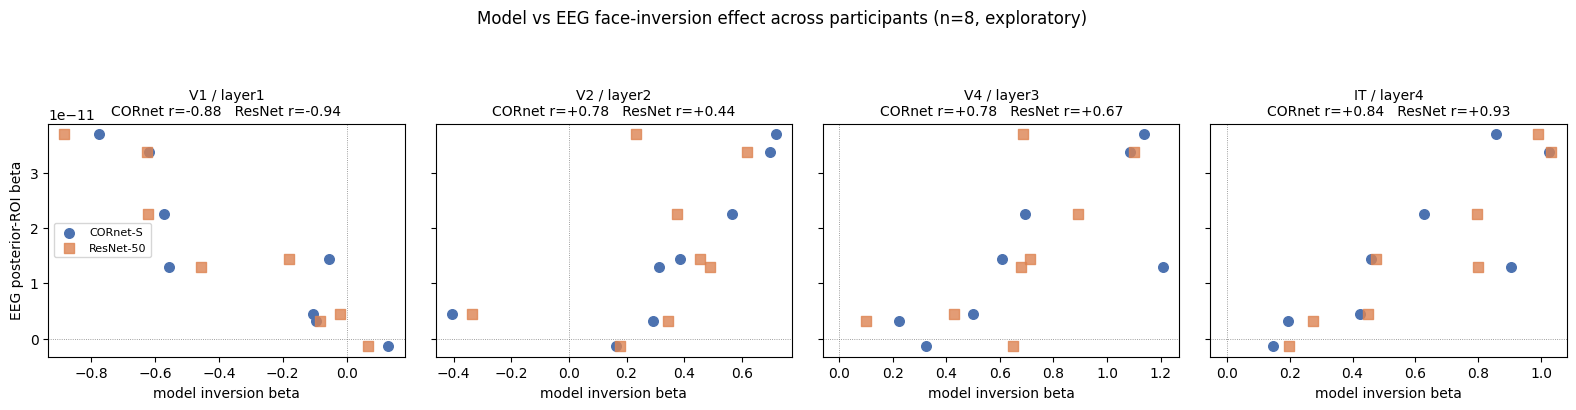

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.9), sharey=True)
for i, (cl, rl) in enumerate(zip(CORNET_LAYERS, RESNET_LAYERS)):
    ax = axes[i]
    ax.scatter(COR_B[cl], EEG_POST, s=48, color="#4C72B0", label="CORnet-S", zorder=3)
    ax.scatter(RES_B[rl], EEG_POST, s=48, color="#DD8452", marker="s",
               label="ResNet-50", alpha=0.8, zorder=3)
    rc = eeg_corr[STAGE_LABELS[i]]["cornet"][0]
    rr = eeg_corr[STAGE_LABELS[i]]["resnet"][0]
    ax.axhline(0, color="grey", lw=0.6, ls=":")
    ax.axvline(0, color="grey", lw=0.6, ls=":")
    ax.set_title(f"{STAGE_LABELS[i]}\nCORnet r={rc:+.2f}   ResNet r={rr:+.2f}", fontsize=10)
    ax.set_xlabel("model inversion beta")
    if i == 0:
        ax.set_ylabel("EEG posterior-ROI beta")
        ax.legend(fontsize=8)
fig.suptitle("Model vs EEG face-inversion effect across participants (n=8, exploratory)",
             fontsize=12, y=1.04)
fig.tight_layout()
plt.show()

## 7. Summary — the numbers the write-up should quote

Printed as one block so Results §5 and §6 can be written straight from this output.

In [11]:
print("=" * 78)
print("MODEL COMPARISON SUMMARY  (event / facecrop / RFX, n=8 subjects)")
print("=" * 78)

print("\n[1] Both models show the face-inversion effect at every stage:")
for i, (cl, rl) in enumerate(zip(CORNET_LAYERS, RESNET_LAYERS)):
    ct, cp = gu.rfx_ttest(COR_B[cl]); rt, rp = gu.rfx_ttest(RES_B[rl])
    print(f"    {STAGE_LABELS[i]:<14} CORnet b={np.mean(COR_B[cl]):+.3f} t={ct:+.2f} p={cp:.4f}"
          f"   |  ResNet b={np.mean(RES_B[rl]):+.3f} t={rt:+.2f} p={rp:.4f}")

print("\n[2] Neither architecture outperforms the other:")
for s, k in comparisons.items():
    print(f"    {s:<14} paired t(7)={k['t']:+.2f}, p={k['p']:.3f}, dz={k['dz']:+.2f}, "
          f"BF01={k['bf01']:.2f}")

print("\n[3] They track each other across stimulus sets (the equivalence claim):")
for s, k in comparisons.items():
    print(f"    {s:<14} r={k['r']:+.3f}, p={k['p_r']:.4f}")

print(f"\n[4] TOST at the pre-specified SESOI of {SESOI_DZ} dz:")
for s, k in comparisons.items():
    print(f"    {s:<14} p_TOST={k['p_tost']:.3f}  "
          f"{'equivalent' if k['equivalent'] else 'INCONCLUSIVE'}")
print(f"    Underpowered by construction: 80% power needs dz="
      f"{gu.min_detectable_dz(len(SUBJECTS)):.2f}.")

print("\n[5] Human benchmark:")
print(f"    this project's replication : t(7)={eeg_t:+.2f}, p={eeg_p:.4f}")
print(f"    published (K&C 2022 Task 2): t(7)=3.71,  p=0.0076")

print("\n[6] Model vs EEG across participants (exploratory, n=8):")
for s, v in eeg_corr.items():
    print(f"    {s:<14} CORnet r={v['cornet'][0]:+.3f} (p={v['cornet'][1]:.3f})   "
          f"ResNet r={v['resnet'][0]:+.3f} (p={v['resnet'][1]:.3f})")
print("=" * 78)

MODEL COMPARISON SUMMARY  (event / facecrop / RFX, n=8 subjects)

[1] Both models show the face-inversion effect at every stage:
    V1 / layer1    CORnet b=-0.331 t=-2.80 p=0.0266   |  ResNet b=-0.350 t=-2.88 p=0.0238
    V2 / layer2    CORnet b=+0.341 t=+2.67 p=0.0320   |  ResNet b=+0.295 t=+2.86 p=0.0242
    V4 / layer3    CORnet b=+0.723 t=+5.36 p=0.0011   |  ResNet b=+0.656 t=+6.26 p=0.0004
    IT / layer4    CORnet b=+0.580 t=+4.99 p=0.0016   |  ResNet b=+0.626 t=+5.55 p=0.0009

[2] Neither architecture outperforms the other:
    V1 / layer1    paired t(7)=+0.65, p=0.534, dz=+0.23, BF01=2.49
    V2 / layer2    paired t(7)=+0.63, p=0.550, dz=+0.22, BF01=2.53
    V4 / layer3    paired t(7)=+0.62, p=0.552, dz=+0.22, BF01=2.53
    IT / layer4    paired t(7)=-1.56, p=0.162, dz=-0.55, BF01=1.23

[3] They track each other across stimulus sets (the equivalence claim):
    V1 / layer1    r=+0.971, p=0.0001
    V2 / layer2    r=+0.816, p=0.0134
    V4 / layer3    r=+0.635, p=0.0907
    IT 

## 8. How to read this

**The effect is real in both models and it is not a CORnet property.** Every stage of both
networks shows a significant inversion effect, and no stage differs between them. Neither
network was trained on faces or on orientation, so this is emergent — but it is emergent
from *hierarchical object training*, not from the architectural biological inspiration that
distinguishes CORnet-S from ResNet-50.

**The equivalence claim rests on the correlation, not on the failure to reject.** A
non-significant paired *t* at n=8 is weak evidence on its own, and the Bayes factors here
are only anecdotal. The cross-model correlation is the substantive result: the two models'
per-subject betas move together almost perfectly at the first and last stages, which means
they are responding to the same across-video variance. Note the direction of that argument —
a shared stimulus set is *why* the correlation is high, and that is the point: the same
stimulus properties drive both.

**What this does not test.** CORnet-S's recurrence is read out only at its final time step,
so this compares the two architectures on a static contrast and says nothing about
recurrent dynamics. And no untrained-network or pixel-luminance baseline was run here, so a
low-level image-statistics account is made unlikely by the early-stage sign reversal but is
not positively excluded.

**The random-effects caveat carries over.** Both networks are deterministic and identical
across subjects; what varies is each participant's video. So t(7) is a random-effects claim
over eight independent stimulus sequences — "robust to which video you show it" — not a
claim about variability across models or people.